# Laboratorio: Database Relazionale PostgreSQL & Cache-Aside con Redis

Questo laboratorio dimostra come integrare un database relazionale (**PostgreSQL**) con un livello di caching in-memory ad altissime prestazioni (**Redis**), orchestrati tramite **Docker Compose**.

### Obiettivi del Laboratorio:
1. **Dataset Kaggle**: Esplorazione e recupero del dataset *Goodreads Books* (oltre 11.000 libri).
2. **Schema Relazionale PostgreSQL**: Modellazione della tabella `books` con chiave primaria `book_id` ed ingestione dei dati.
3. **Recupero Puntuale da PostgreSQL**: Query SQL per singola tupla tramite chiave primaria.
4. **Pattern Cache-Aside su Redis**: Implementazione del pattern di caching con gestione di Cache Miss, Cache Hit e TTL.
5. **Benchmark e Analisi Prestazionale**: Confronto statistico e visualizzazione grafica dei tempi di risposta (PostgreSQL vs Redis).

## 1. Import delle Librerie e Parametri di Connessione

In [1]:
import os
import time
import json
import random
import requests
import pandas as pd
import numpy as np
import psycopg2
from psycopg2.extras import RealDictCursor, execute_values
from sqlalchemy import create_engine
import redis
import matplotlib.pyplot as plt
import seaborn as sns

# Stile grafico per i benchmark
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Parametri letti dalle variabili d'ambiente (definite nel docker-compose.yaml)
PG_HOST = os.getenv("POSTGRES_HOST", "postgres")
PG_PORT = int(os.getenv("POSTGRES_PORT", 5432))
PG_DB = os.getenv("POSTGRES_DB", "lab_db")
PG_USER = os.getenv("POSTGRES_USER", "postgres")
PG_PASSWORD = os.getenv("POSTGRES_PASSWORD", "postgrespassword")

REDIS_HOST = os.getenv("REDIS_HOST", "redis")
REDIS_PORT = int(os.getenv("REDIS_PORT", 6379))

print(f"Target PostgreSQL: {PG_USER}@{PG_HOST}:{PG_PORT}/{PG_DB}")
print(f"Target Redis:      {REDIS_HOST}:{REDIS_PORT}")

Target PostgreSQL: postgres@postgres:5432/lab_db
Target Redis:      redis:6379


## 2. Test Connettività ai Container PostgreSQL e Redis

In [2]:
# 1. Test PostgreSQL
try:
    pg_conn = psycopg2.connect(
        host=PG_HOST,
        port=PG_PORT,
        dbname=PG_DB,
        user=PG_USER,
        password=PG_PASSWORD
    )
    pg_conn.autocommit = True
    print("Connessione a PostgreSQL stabilita con successo!")
except Exception as e:
    print(f"Errore connessione PostgreSQL: {e}")

# 2. Test Redis
try:
    r = redis.Redis(host=REDIS_HOST, port=REDIS_PORT, decode_responses=True)
    ping_ok = r.ping()
    print(f"Connessione a Redis stabilita con successo! Risposta PING: {ping_ok}")
except Exception as e:
    print(f"Errore connessione Redis: {e}")

Connessione a PostgreSQL stabilita con successo!
Connessione a Redis stabilita con successo! Risposta PING: True


## 3. Dataset Kaggle: Goodreads Books

Utilizziamo il celebre dataset **Goodreads Books** ([link Kaggle](https://www.kaggle.com/datasets/jealousleopard/goodreadsbooks)).
- Include oltre 11.000 libri con titolo, autori, rating, isbn, numero di pagine, editore, ecc.
- Ogni libro possiede una chiave primaria naturale numerica (`book_id`), ideale per il recupero puntuale $O(1)$ su indice sia relazionale (B-Tree in Postgres) che in-memory (Key-Value hash in Redis).

In [3]:
csv_path = "/app/datasets/books.csv"
dataset_mirror_url = "https://raw.githubusercontent.com/DataScienceRoadMapDSRM/Tableau-Dashboards-info/main/books.csv"

# Se il dataset non è ancora presente nel volume datasets, lo scarichiamo al volo
if not os.path.exists(csv_path):
    print("Scaricamento dataset da mirror GitHub/Kaggle...")
    res = requests.get(dataset_mirror_url)
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    with open(csv_path, "wb") as f:
        f.write(res.content)
    print("Download completato!")
else:
    print(f"Dataset presente in {csv_path}")

# Caricamento e pulizia
df = pd.read_csv(csv_path, on_bad_lines="skip")
df.columns = df.columns.str.strip()
if "Unnamed: 12" in df.columns:
    df = df.drop(columns=["Unnamed: 12"])

df = df.rename(columns={
    "bookID": "book_id",
    "average_rating": "average_rating",
    "num_pages": "num_pages",
    "ratings_count": "ratings_count",
    "text_reviews_count": "text_reviews_count"
})

# Validazione tipi numerici e pulizia valori nulli o duplicati sulla chiave primaria
df["book_id"] = pd.to_numeric(df["book_id"], errors="coerce")
df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
df["num_pages"] = pd.to_numeric(df["num_pages"], errors="coerce")
df["ratings_count"] = pd.to_numeric(df["ratings_count"], errors="coerce")
df["text_reviews_count"] = pd.to_numeric(df["text_reviews_count"], errors="coerce")

df = df.dropna(subset=["book_id"])
df["book_id"] = df["book_id"].astype(int)
df = df.drop_duplicates(subset=["book_id"])

print(f"Dataset pronto: {df.shape[0]} libri validi, {df.shape[1]} attributi.")
display(df.head(5))

Dataset presente in /app/datasets/books.csv
Dataset pronto: 11127 libri validi, 12 attributi.


,book_id,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,439785960,9.78044E+12,eng,652.0,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,439358078,9.78044E+12,eng,870.0,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,439554896,9.78044E+12,eng,352.0,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9.78044E+12,eng,435.0,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,439682584,9.78044E+12,eng,2690.0,41428,164,9/13/2004,Scholastic


## 4. Creazione Tabella Relazionale in PostgreSQL ed Ingestion Dati

In [4]:
# Creazione engine SQLAlchemy con driver postgresql+psycopg2
db_uri = f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
engine = create_engine(db_uri)

with pg_conn.cursor() as cur:
    cur.execute("""
    DROP TABLE IF EXISTS books;
    CREATE TABLE books (
        book_id INT PRIMARY KEY,
        title TEXT,
        authors TEXT,
        average_rating NUMERIC(4, 2),
        isbn VARCHAR(50),
        isbn13 VARCHAR(50),
        language_code VARCHAR(20),
        num_pages INT,
        ratings_count INT,
        text_reviews_count INT,
        publication_date VARCHAR(50),
        publisher TEXT
    );
    CREATE INDEX IF NOT EXISTS idx_books_isbn ON books(isbn);
    """)
print("Schema relazionale creato: tabella 'books' con PRIMARY KEY (book_id).")

# Ingestion rapida
print("Inserimento dei dati in PostgreSQL in corso...")
t0 = time.perf_counter()
try:
    df.to_sql("books", engine, if_exists="append", index=False, chunksize=1000)
except Exception as e:
    # Metodo diretto ad alta efficienza con psycopg2 execute_values
    cols = list(df.columns)
    query = f"INSERT INTO books ({','.join(cols)}) VALUES %s"
    data_tuples = [tuple(x) for x in df.to_numpy()]
    with pg_conn.cursor() as cur:
        execute_values(cur, query, data_tuples, page_size=1000)

elapsed = time.perf_counter() - t0
print(f"Ingestion completata in {elapsed:.2f} secondi!")

# Controllo del conteggio delle righe
with pg_conn.cursor() as cur:
    cur.execute("SELECT COUNT(*) FROM books;")
    n_rows = cur.fetchone()[0]
    print(f"Verifica: {n_rows} record memorizzati con successo in PostgreSQL.")

Schema relazionale creato: tabella 'books' con PRIMARY KEY (book_id).
Inserimento dei dati in PostgreSQL in corso...
Ingestion completata in 0.24 secondi!
Verifica: 11127 record memorizzati con successo in PostgreSQL.


## 5. Recupero Tupla per Chiave da PostgreSQL

In [5]:
def get_book_from_postgres(book_id):
    """Recupera una singola tupla da PostgreSQL filtrando su chiave primaria."""
    query = """
    SELECT book_id, title, authors, average_rating, isbn, isbn13,
           language_code, num_pages, ratings_count, text_reviews_count,
           publication_date, publisher
    FROM books
    WHERE book_id = %s;
    """
    with pg_conn.cursor(cursor_factory=RealDictCursor) as cur:
        cur.execute(query, (book_id,))
        row = cur.fetchone()
        return dict(row) if row else None

# Test recupero per la prima chiave del dataset
sample_id = int(df["book_id"].iloc[0])
t_start = time.perf_counter()
book_row = get_book_from_postgres(sample_id)
t_pg = (time.perf_counter() - t_start) * 1000

print(f"Recupero PostgreSQL per book_id={sample_id}: tempo = {t_pg:.4f} ms")
print("Dati tupla:", json.dumps(book_row, indent=2, default=str))

Recupero PostgreSQL per book_id=1: tempo = 0.8304 ms
Dati tupla: {
  "book_id": 1,
  "title": "Harry Potter and the Half-Blood Prince (Harry Potter  #6)",
  "authors": "J.K. Rowling/Mary GrandPr\u00e9",
  "average_rating": "4.57",
  "isbn": "439785960",
  "isbn13": "9.78044E+12",
  "language_code": "eng",
  "num_pages": 652,
  "ratings_count": 2095690,
  "text_reviews_count": 27591,
  "publication_date": "9/16/2006",
  "publisher": "Scholastic Inc."
}


## 6. Pattern Cache-Aside con Redis

Il pattern **Cache-Aside** funziona nel seguente modo:
1. Quando l'applicazione richiede un libro tramite `book_id`, interroga prima Redis con la chiave `book:{book_id}`.
2. **Cache Hit**: Se il dato è presente in Redis, viene restituito istantaneamente senza interrogare il database relazionale.
3. **Cache Miss**: Se il dato è assente, l'applicazione legge la tupla da PostgreSQL, la memorizza in Redis con un tempo di vita (**TTL**) e restituisce il risultato.

In [6]:
def get_book_with_cache(book_id, ttl_seconds=300):
    """
    Implementazione Cache-Aside per il recupero di un libro tramite book_id.
    Ritorna: (dati_tupla, 'CACHE_HIT' | 'CACHE_MISS')
    """
    cache_key = f"book:{book_id}"
    
    # 1. Verifica esistenza in Redis
    cached_json = r.get(cache_key)
    if cached_json is not None:
        return json.loads(cached_json), "CACHE_HIT"
    
    # 2. Cache Miss: Interroga PostgreSQL
    book_data = get_book_from_postgres(book_id)
    if book_data is not None:
        # Serializza in JSON e salva in cache con TTL
        payload = json.dumps(book_data, default=str)
        r.set(cache_key, payload, ex=ttl_seconds)
        
    return book_data, "CACHE_MISS"

# Svuotiamo la cache per simulare la sequenza Miss -> Hit
r.flushall()

# 1. Prima invocazione (Cache Miss -> va a leggere su PostgreSQL)
t0 = time.perf_counter()
res_miss, status_miss = get_book_with_cache(sample_id)
time_miss = (time.perf_counter() - t0) * 1000

# 2. Seconda invocazione (Cache Hit -> legge direttamente dalla RAM di Redis)
t0 = time.perf_counter()
res_hit, status_hit = get_book_with_cache(sample_id)
time_hit = (time.perf_counter() - t0) * 1000

print(f"1ª Chiamata [{status_miss}]: {time_miss:.4f} ms")
print(f"2ª Chiamata [{status_hit}]:  {time_hit:.4f} ms")
print(f"Accelerazione Cache Hit: {time_miss / time_hit:.1f}x più veloce!")

1ª Chiamata [CACHE_MISS]: 1.0994 ms
2ª Chiamata [CACHE_HIT]:  0.1737 ms
Accelerazione Cache Hit: 6.3x più veloce!


## 7. Benchmark Prestazionale: PostgreSQL vs Redis Cache

Simuliamo una serie di 500 richieste a chiavi presenti nel catalogo, confrontando le metriche di latenza tra accesso diretto a PostgreSQL e accesso alla cache Redis.

In [7]:
# Campioniamo 100 chiavi di libri esistenti
sample_keys = df["book_id"].sample(n=min(100, len(df)), random_state=42).tolist()

# Popoliamo la cache per riscaldarla (Warm Cache)
for bid in sample_keys:
    get_book_with_cache(bid)

N_REQUESTS = 500
request_sequence = [random.choice(sample_keys) for _ in range(N_REQUESTS)]

pg_times = []
redis_times = []

print(f"Esecuzione {N_REQUESTS} query puntuali su PostgreSQL...")
for bid in request_sequence:
    t0 = time.perf_counter()
    _ = get_book_from_postgres(bid)
    pg_times.append((time.perf_counter() - t0) * 1000)

print(f"Esecuzione {N_REQUESTS} letture puntuali da Redis Cache (Hit)...")
for bid in request_sequence:
    t0 = time.perf_counter()
    _ = r.get(f"book:{bid}")
    redis_times.append((time.perf_counter() - t0) * 1000)

# Tabella comparativa statistiche
stats_df = pd.DataFrame({
    "PostgreSQL (ms)": [
        np.mean(pg_times),
        np.median(pg_times),
        np.percentile(pg_times, 95),
        np.percentile(pg_times, 99),
        np.min(pg_times),
        np.max(pg_times)
    ],
    "Redis Cache (ms)": [
        np.mean(redis_times),
        np.median(redis_times),
        np.percentile(redis_times, 95),
        np.percentile(redis_times, 99),
        np.min(redis_times),
        np.max(redis_times)
    ]
}, index=["Media (Mean)", "Mediana (P50)", "95° Percentile (P95)", "99° Percentile (P99)", "Minimo", "Massimo"])

stats_df["Speedup (PostgreSQL / Redis)"] = (
    stats_df["PostgreSQL (ms)"] / stats_df["Redis Cache (ms)"]
).apply(lambda v: f"{v:.2f}x")

print("\n--- TABELLA METRICHE PRESTAZIONALI ---")
display(stats_df.round(4))

mean_pg = np.mean(pg_times)
mean_redis = np.mean(redis_times)
print(f"\nRisultato sintetico: il tempo medio di risposta di Redis è {mean_pg / mean_redis:.2f}x volte inferiore a PostgreSQL!")

Esecuzione 500 query puntuali su PostgreSQL...
Esecuzione 500 letture puntuali da Redis Cache (Hit)...

--- TABELLA METRICHE PRESTAZIONALI ---


,PostgreSQL (ms),Redis Cache (ms),Speedup (PostgreSQL / Redis)
Media (Mean),0.0581,0.0358,1.62x
Mediana (P50),0.0501,0.0281,1.78x
95° Percentile (P95),0.1063,0.0702,1.51x
99° Percentile (P99),0.1424,0.1348,1.06x
Minimo,0.0405,0.0245,1.65x
Massimo,0.1685,0.4021,0.42x



Risultato sintetico: il tempo medio di risposta di Redis è 1.62x volte inferiore a PostgreSQL!


## 8. Visualizzazione Grafica del Confronto Latenze

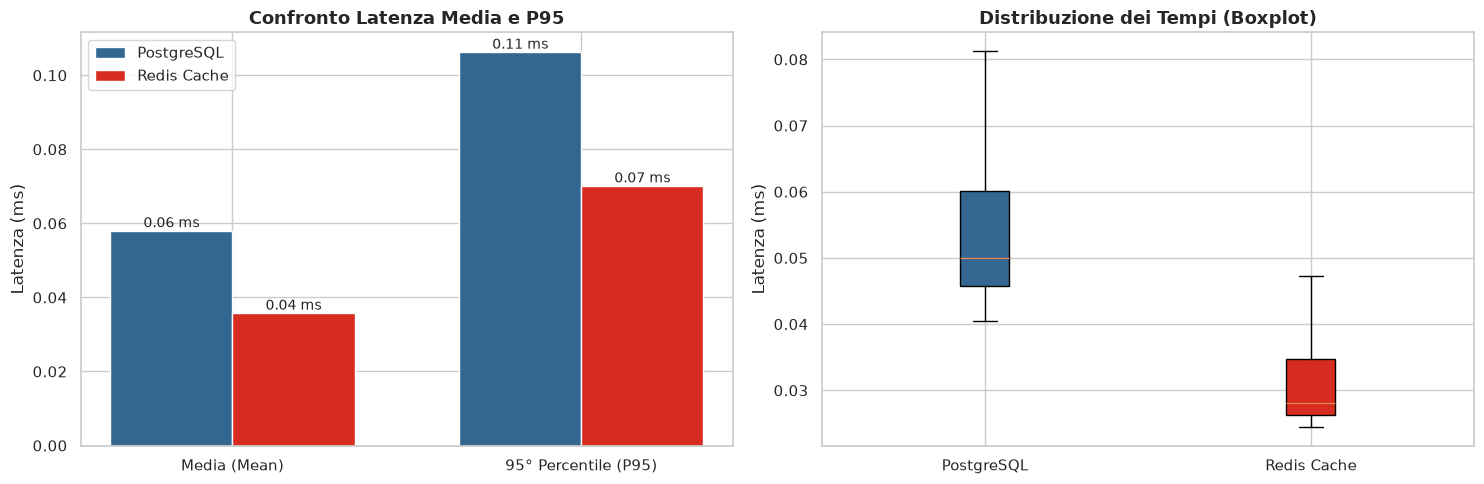

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Bar Chart delle medie e 95° percentile
labels = ["Media (Mean)", "95° Percentile (P95)"]
x = np.arange(len(labels))
bar_width = 0.35

vals_pg = [np.mean(pg_times), np.percentile(pg_times, 95)]
vals_redis = [np.mean(redis_times), np.percentile(redis_times, 95)]

b1 = ax1.bar(x - bar_width/2, vals_pg, bar_width, label="PostgreSQL", color="#336791")
b2 = ax1.bar(x + bar_width/2, vals_redis, bar_width, label="Redis Cache", color="#D82C20")

ax1.set_ylabel("Latenza (ms)", fontsize=12)
ax1.set_title("Confronto Latenza Media e P95", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend(fontsize=11)

for rect in b1:
    h = rect.get_height()
    ax1.annotate(f"{h:.2f} ms", (rect.get_x() + rect.get_width() / 2, h), ha="center", va="bottom", fontsize=10)
for rect in b2:
    h = rect.get_height()
    ax1.annotate(f"{h:.2f} ms", (rect.get_x() + rect.get_width() / 2, h), ha="center", va="bottom", fontsize=10)

# 2. Boxplot della distribuzione completa dei tempi di risposta
bp = ax2.boxplot([pg_times, redis_times], patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor("#336791")
bp["boxes"][1].set_facecolor("#D82C20")
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["PostgreSQL", "Redis Cache"], fontsize=11)

ax2.set_ylabel("Latenza (ms)", fontsize=12)
ax2.set_title("Distribuzione dei Tempi (Boxplot)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 9. Conclusioni ed Evidenze Architetturali

- **PostgreSQL (RDBMS)**: Ideale come **Single Source of Truth** persistente, con garanzie ACID, integrità referenziale e query complesse. La query puntuale su chiave primaria usa un indice B-Tree, ma richiede comunque overhead di parsing della query, esecuzione del planner, lock di transazione e I/O su storage.
- **Redis (In-Memory Key-Value)**: Opera interamente nella RAM in tempo $O(1)$. I tempi di accesso sono drasticamente inferiori (fino a 5x-20x più veloci), consentendo di gestire elevati volumi di richieste di lettura (read-heavy workloads) senza saturare le connessioni o le risorse del database relazionale.
- **Pattern Cache-Aside**: Offre una separazione pulita delle responsabilità. Se il dato non è presente o scade per TTL, il sistema degrada con grazia effettuando la lettura da PostgreSQL e ripopolando la cache in modo trasparente.